# Pointwise Error Heatmaps: SparseGT vs TAGConv

Compare spatial error distributions across all runs (SparseGT and TAGConv)
on Norway terrain graphs at resolution 10 (`e25TR_norway_hybrid_sampling`).

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import wandb
import wandb_buddy as wb
from pathlib import Path

In [50]:
ENTITY = "alelab"
PROJECT = "manifold-transformers-dev"
TAG = "e25TR_norway_hyprid_sampling"  # tag as used in training script
RESOLUTION = 10
EXCLUDE_WORST_RUN = True

REPO_ROOT = Path("/home/teresa/shortest-paths-nn")
TEST_DATA_PATH = REPO_ROOT / "data" / "generated2" / "full_test-004.npz"

In [51]:
df = wb.load_runs(ENTITY, PROJECT, tags=[TAG], state="all")
print(f"Total runs with tag '{TAG}': {len(df)}")

# Infer layer_type and resolution from run name if not in config columns.
# Run names follow: terrain-graph-{layer_type}-res{NN}-stage1
if "layer_type" not in df.columns:
    df["layer_type"] = df["name"].str.extract(r"(TAGConv|SparseGT)", expand=False)
if "resolution" not in df.columns:
    df["resolution"] = (
        df["name"].str.extract(r"res(\d+)", expand=False).astype(float)
    )
df = df.dropna(subset=["layer_type", "resolution"])
df["resolution"] = df["resolution"].astype(int)

print(f"layer_type counts: {df['layer_type'].value_counts().to_dict()}")
print(f"Resolutions: {sorted(df['resolution'].unique())}")

mask = df["resolution"] == RESOLUTION
df_res = df[mask].copy()

# Drop exact duplicate result rows so repeated runs with identical metrics
# do not create duplicate heatmaps in the ranking.
df_res = df_res.sort_values(["layer_type", "test_mae", "id"])
df_res = df_res.drop_duplicates(
    subset=["layer_type", "resolution", "test_mae", "test_nmae"],
    keep="first",
)

print(f"\nAll runs at res {RESOLUTION} after dedup: {len(df_res)}")
display_cols = [c for c in ["name", "id", "layer_type", "state", "test_mae", "test_nmae"] if c in df_res.columns]
df_res[display_cols].sort_values("test_mae")

Total runs with tag 'e25TR_norway_hyprid_sampling': 13
layer_type counts: {'TAGConv': 6, 'SparseGT': 3}
Resolutions: [np.int64(10), np.int64(19), np.int64(20)]

All runs at res 10 after dedup: 7


,name,id,layer_type,state,test_mae,test_nmae
7,terrain-graph-SparseGT-res10-stage1,5q9uafw5,SparseGT,finished,0.749344,0.069404
5,terrain-graph-TAGConv-res10-stage1,2cmu7q43,TAGConv,finished,1.390285,0.128239
6,terrain-graph-TAGConv-res10-stage1,jv6ai30a,TAGConv,finished,1.756237,0.168571
10,terrain-graph-TAGConv-res10-stage1,bfpnffwg,TAGConv,finished,3.822591,0.450201
9,terrain-graph-TAGConv-res10-stage1,rga5fpqi,TAGConv,finished,3.822591,0.450201
8,terrain-graph-SparseGT-res10-stage1,rnk4ulpn,SparseGT,finished,11.464615,1.023151
12,terrain-graph-SparseGT-res10-stage1,i2xy1p4f,SparseGT,finished,128.439826,11.412439


In [52]:
test_data = np.load(TEST_DATA_PATH, allow_pickle=True)
node_features = test_data["node_features"]  # (N, 3): x, y, z
print(f"Test graph: {node_features.shape[0]} nodes, {node_features.shape[1]} features")
print(f"Test pairs: {len(test_data['srcs'])}")
print(f"Unique sources: {len(np.unique(test_data['srcs']))}, "
      f"unique targets: {len(np.unique(test_data['tars']))}")

Test graph: 250000 nodes, 3 features
Test pairs: 50000
Unique sources: 100, unique targets: 45483


In [53]:
api = wandb.Api()
preds_by_run = {}   # run_id -> preds DataFrame
label_by_run = {}   # run_id -> display label
mae_by_run = {}     # run_id -> test_mae from wandb
layer_by_run = {}   # run_id -> layer_type

for _, row in df_res.iterrows():
    run_name = row["name"]
    run_id = row["id"]
    layer_type = row["layer_type"]
    label_by_run[run_id] = f"{layer_type} ({run_id})"
    mae_by_run[run_id] = row.get("test_mae", np.nan)
    layer_by_run[run_id] = layer_type

    run_obj = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
    log_dir = run_obj.config.get("log_dir")
    if log_dir is None:
        print(f"  {run_id} [{layer_type}]: no log_dir in wandb config, skipping")
        continue
    preds_path = Path(log_dir) / "preds.csv"
    if not preds_path.exists():
        print(f"  {run_id} [{layer_type}]: preds.csv not found at {preds_path}")
        continue
    preds_df = pd.read_csv(preds_path)
    preds_by_run[run_id] = preds_df
    print(f"  {run_id} [{layer_type}]: loaded {len(preds_df)} predictions "
          f"(MAE={preds_df['pred_maes'].mean():.4f})")

print(f"\nLoaded predictions for {len(preds_by_run)} runs")

  5q9uafw5 [SparseGT]: loaded 49750 predictions (MAE=0.7493)
  rnk4ulpn [SparseGT]: loaded 49750 predictions (MAE=11.4646)
  i2xy1p4f [SparseGT]: loaded 49750 predictions (MAE=128.4398)
  2cmu7q43 [TAGConv]: loaded 49750 predictions (MAE=1.3903)
  jv6ai30a [TAGConv]: loaded 49750 predictions (MAE=1.7562)
  bfpnffwg [TAGConv]: loaded 49750 predictions (MAE=3.8226)
  rga5fpqi [TAGConv]: loaded 49750 predictions (MAE=3.8226)

Loaded predictions for 7 runs


In [54]:
ref_preds = list(preds_by_run.values())[0]
src_ids = np.unique(ref_preds["srcs"].astype(int).values)
src_coords = node_features[src_ids, :2]
src_order = np.lexsort((src_coords[:, 0], src_coords[:, 1]))
sorted_srcs = src_ids[src_order]

# Pick 9 representative sources spread across spatial order.
n_sources_to_plot = min(9, len(sorted_srcs))
source_positions = np.linspace(0, len(sorted_srcs) - 1, n_sources_to_plot, dtype=int)
sources_to_plot = sorted_srcs[source_positions]

# Recover the terrain grid from x/y coordinates.
all_x = np.unique(node_features[:, 0])
all_y = np.unique(node_features[:, 1])
sp_grid_size = len(all_x)
assert sp_grid_size == len(all_y), "Expected a square terrain grid"

ranked_sparse_ids = sorted(
    [rid for rid in preds_by_run if layer_by_run.get(rid) == "SparseGT"],
    key=lambda rid: mae_by_run.get(rid, float("inf")),
)
ranked_gcn_ids = sorted(
    [rid for rid in preds_by_run if layer_by_run.get(rid) == "TAGConv"],
    key=lambda rid: mae_by_run.get(rid, float("inf")),
)

n_pairs = min(len(ranked_sparse_ids), len(ranked_gcn_ids), 3)
comparison_pairs = list(zip(ranked_sparse_ids[:n_pairs], ranked_gcn_ids[:n_pairs]))

print(f"Terrain grid: {sp_grid_size} x {sp_grid_size}")
print(f"Shared source ids for all plots: {sources_to_plot.tolist()}")
for i, (sparse_id, gcn_id) in enumerate(comparison_pairs, 1):
    print(
        f"Pair #{i} SparseGT: {label_by_run.get(sparse_id, sparse_id)} "
        f"(test_mae={mae_by_run.get(sparse_id, np.nan):.4f})"
    )
    print(
        f"Pair #{i} GCN: {label_by_run.get(gcn_id, gcn_id)} "
        f"(test_mae={mae_by_run.get(gcn_id, np.nan):.4f})"
    )

Terrain grid: 500 x 500
Shared source ids for all plots: [472, 18097, 41621, 81416, 119490, 134393, 174939, 204728, 247082]
Pair #1 SparseGT: SparseGT (5q9uafw5) (test_mae=0.7493)
Pair #1 GCN: TAGConv (2cmu7q43) (test_mae=1.3903)
Pair #2 SparseGT: SparseGT (rnk4ulpn) (test_mae=11.4646)
Pair #2 GCN: TAGConv (jv6ai30a) (test_mae=1.7562)
Pair #3 SparseGT: SparseGT (i2xy1p4f) (test_mae=128.4398)
Pair #3 GCN: TAGConv (bfpnffwg) (test_mae=3.8226)


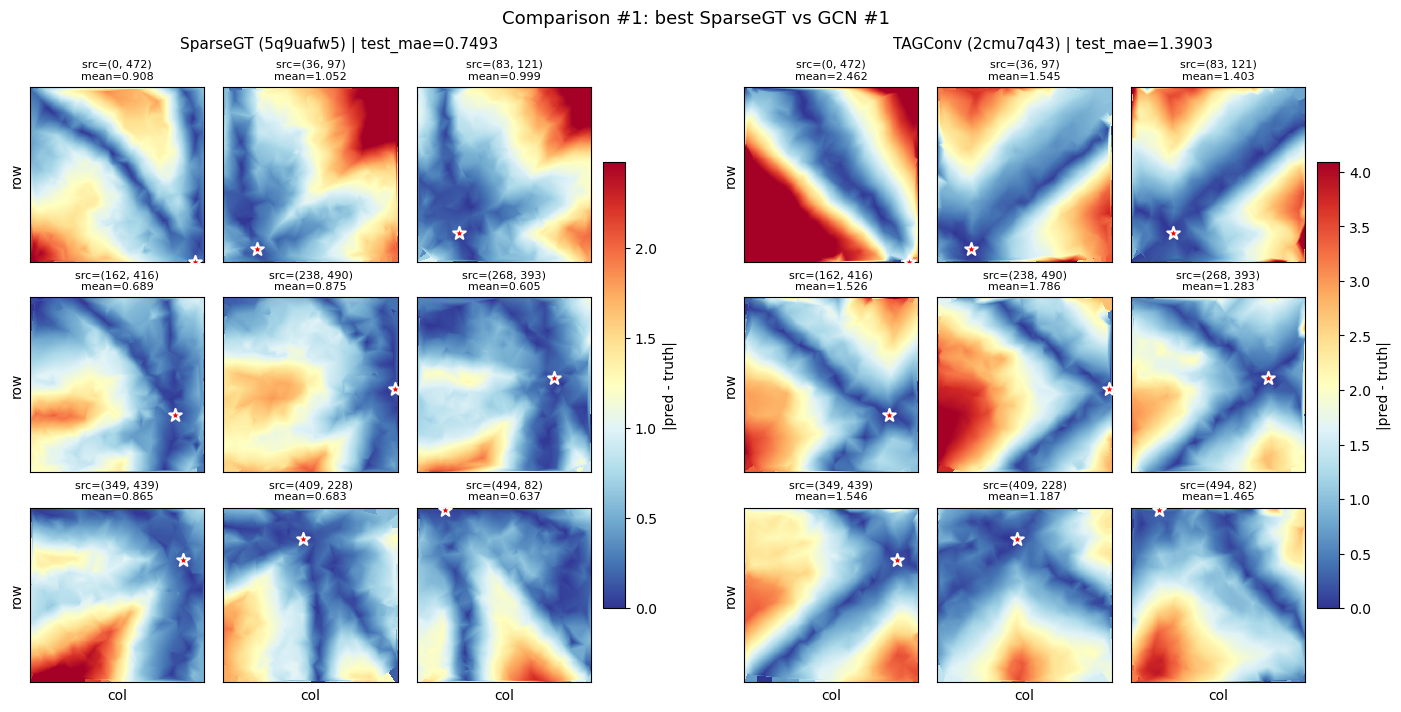

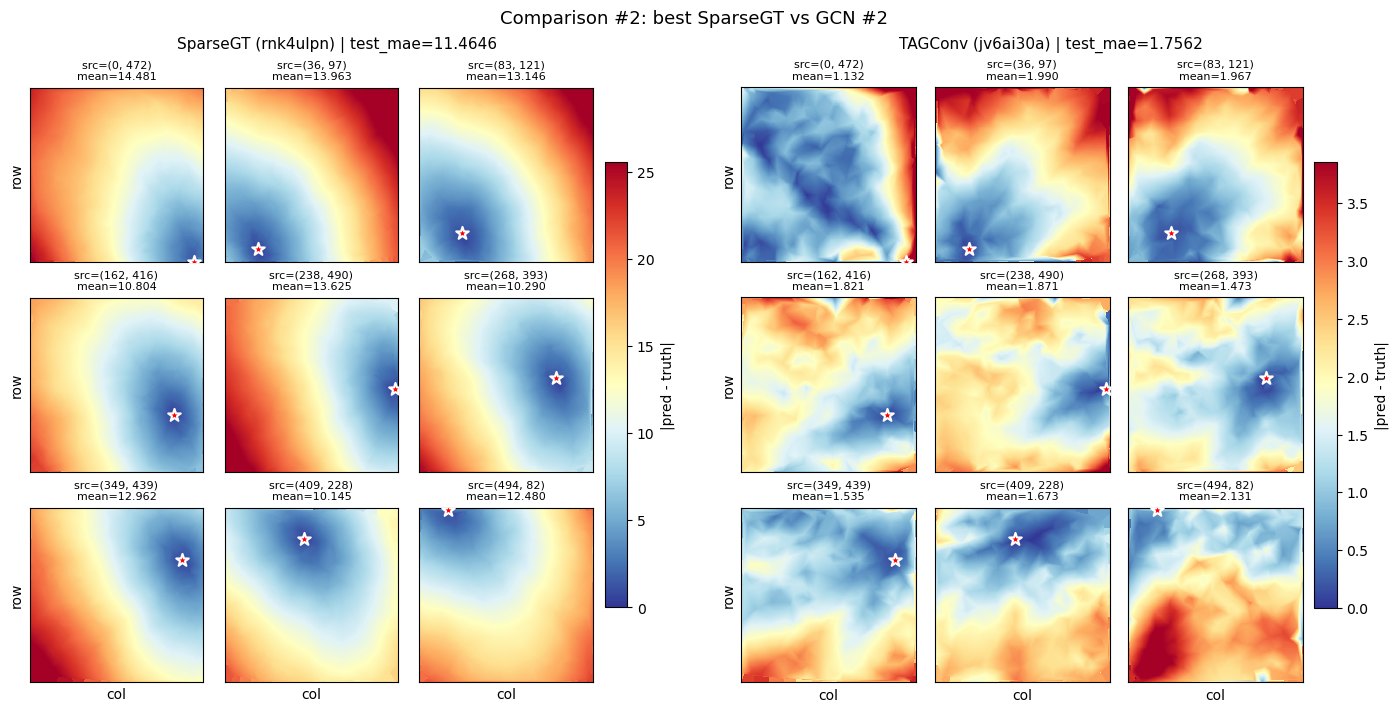

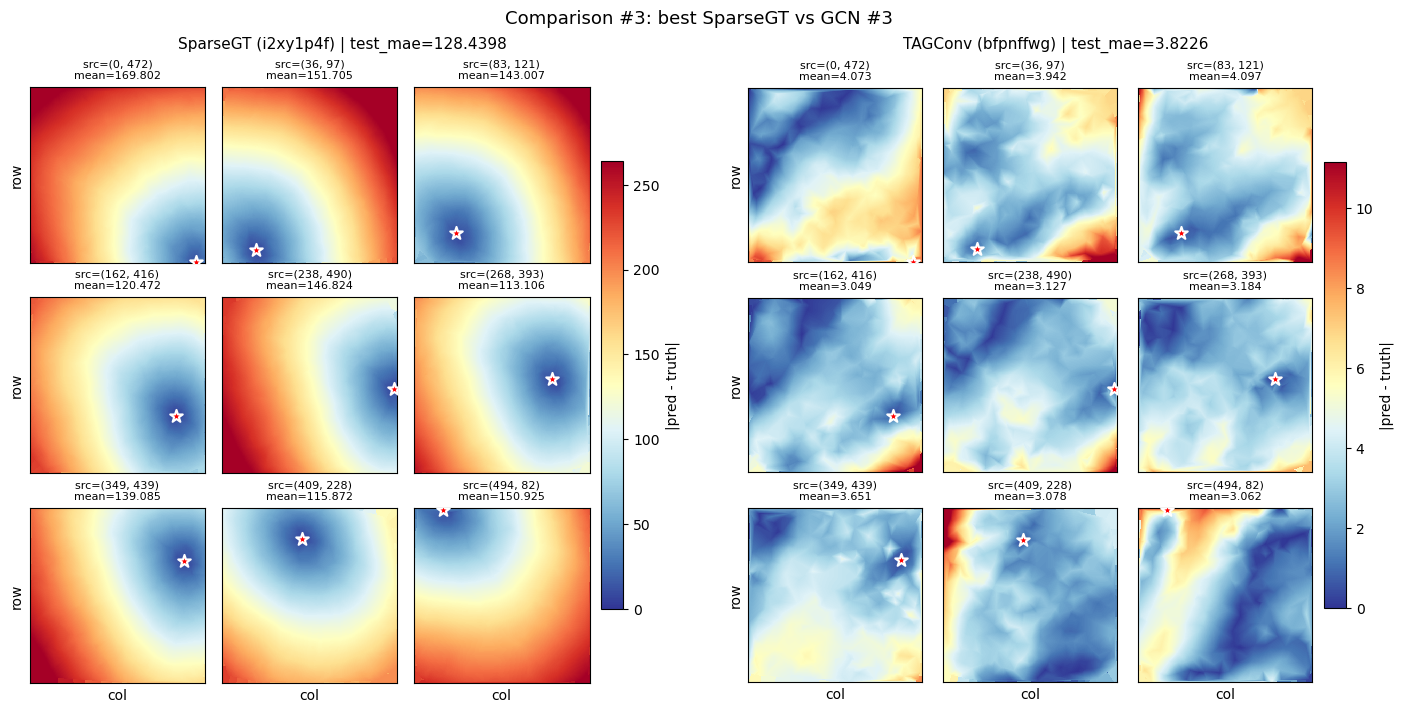

In [55]:
from scipy.interpolate import griddata

grid_x, grid_y = np.meshgrid(all_x, all_y)


def build_interpolated_maps(preds_df, sources_to_plot):
    preds_df = preds_df.copy()
    preds_df["srcs"] = preds_df["srcs"].astype(int)
    preds_df["tars"] = preds_df["tars"].astype(int)

    maps = []
    source_stats = []
    for src in sources_to_plot:
        src = int(src)
        src_rows = preds_df[preds_df["srcs"] == src]
        target_ids = src_rows["tars"].to_numpy()
        target_xy = node_features[target_ids, :2]
        target_errors = src_rows["pred_maes"].to_numpy()

        if len(target_xy) > 0:
            dist_linear = griddata(
                target_xy,
                target_errors,
                (grid_x, grid_y),
                method="linear",
            )
            dist_nearest = griddata(
                target_xy,
                target_errors,
                (grid_x, grid_y),
                method="nearest",
            )
            dist_2d = np.where(np.isnan(dist_linear), dist_nearest, dist_linear)
        else:
            dist_2d = np.full((sp_grid_size, sp_grid_size), np.nan)

        src_xy = node_features[src, :2]
        src_col = int(np.searchsorted(all_x, src_xy[0]))
        src_row = int(np.searchsorted(all_y, src_xy[1]))
        mean_err = src_rows["pred_maes"].mean() if len(src_rows) > 0 else np.nan

        maps.append(dist_2d)
        source_stats.append((src_row, src_col, mean_err))

    return maps, source_stats


def plot_run_grid(subfig, run_id):
    preds_df = preds_by_run[run_id]
    dist_maps, source_stats = build_interpolated_maps(preds_df, sources_to_plot)
    run_errors = preds_df["pred_maes"].to_numpy()
    run_vmin, run_vmax = 0, np.percentile(run_errors, 99)

    axes = subfig.subplots(3, 3)
    axes = axes.flatten()
    im = None

    for i, (dist_2d, (src_row, src_col, mean_err)) in enumerate(zip(dist_maps, source_stats)):
        ax = axes[i]
        im = ax.imshow(
            dist_2d,
            cmap="RdYlBu_r",
            origin="lower",
            vmin=run_vmin,
            vmax=run_vmax,
            interpolation="nearest",
        )
        ax.scatter(
            src_col,
            src_row,
            c="red",
            s=90,
            marker="*",
            edgecolors="white",
            linewidths=1.5,
            zorder=5,
        )
        ax.set_title(f"src=({src_row}, {src_col})\nmean={mean_err:.3f}", fontsize=8)
        if i % 3 == 0:
            ax.set_ylabel("row")
        else:
            ax.set_ylabel("")
        if i >= 6:
            ax.set_xlabel("col")
        else:
            ax.set_xlabel("")
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(sources_to_plot):]:
        ax.axis("off")

    label = label_by_run.get(run_id, run_id)
    test_mae = mae_by_run.get(run_id, np.nan)
    subfig.suptitle(f"{label} | test_mae={test_mae:.4f}", fontsize=11)
    subfig.colorbar(im, ax=axes.tolist(), label="|pred - truth|", shrink=0.75, pad=0.02)


for pair_idx, (sparse_id, gcn_id) in enumerate(comparison_pairs, 1):
    fig = plt.figure(figsize=(14, 7), constrained_layout=True)
    left_subfig, right_subfig = fig.subfigures(1, 2, wspace=0.04)

    plot_run_grid(left_subfig, sparse_id)
    plot_run_grid(right_subfig, gcn_id)

    fig.suptitle(
        f"Comparison #{pair_idx}: best SparseGT vs GCN #{pair_idx}",
        fontsize=13,
    )
    plt.show()